In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from csv_reader import read_csv
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

In [2]:
def plot_losses(data_paths, xlim=None, ylim=None, thresh=2000):
    dps_under_thresh = []
    for dp in data_paths:
        fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

        for i in range(2):
            axs[i].grid(zorder=0, linestyle='--', linewidth=0.5, alpha=0.7)
            axs[i].set_axisbelow(True)
            axs[i].yaxis.set_major_locator(MultipleLocator(1000))  # grid every 1.0 on y-axis
        
        o = read_csv(os.path.join('sims_out', dp, 'train_data.csv'), read_header=False)
        losses = np.array(o.iloc[:, 1])
        axs[0].scatter(np.arange(len(losses)), losses, s=1, c='black', zorder=1)
        axs[0].set_ylim(0, 10000)
        if xlim is not None:
            axs[0].set_xlim(*xlim)
        if ylim is not None:
            axs[0].set_ylim(*ylim)

        o = read_csv(os.path.join('sims_out', dp, 'test_data.csv'), read_header=False)
        x = np.array(o.iloc[:, 0])
        losses_test = np.array(o.iloc[:, 1])
        axs[1].scatter(x, losses_test, s=1, c='black', zorder=1)
        axs[1].set_ylim(0, 10000)
        if xlim is not None:
            axs[1].set_xlim(*xlim)
        if ylim is not None:
            axs[1].set_ylim(*ylim)

        if (losses_test < thresh).any():
            dps_under_thresh.append(dp)
        print(losses_test.min())

        axs[0].set_ylabel('Loss')
        axs[0].set_xlabel('Epochs')
            
        format_plot(axs)
    for dp in dps_under_thresh:
        print(dp)

# 2D results

### 2D network, 300ms integration, no heterogeneity

In [3]:
data_paths = [
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:42:48.164001_run_000850',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:42:53.695039_run_000851',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:42:53.695044_run_000852',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:42:53.695038_run_000853',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:42:53.695043_run_000854',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:42:53.695043_run_000855',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:42:52.783976_run_000856',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:42:52.783974_run_000857',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:42:52.783974_run_000858',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:42:52.783976_run_000859',
]

2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:42:48.164001_run_000850
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:42:53.695039_run_000851
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:42:53.695044_run_000852
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:42:53.695038_run_000853
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:42:53.695043_run_000854
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:42:53.695043_run_000855
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_1

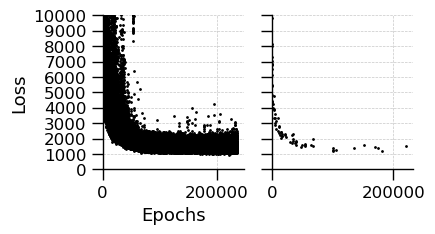

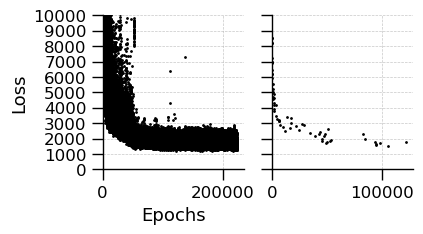

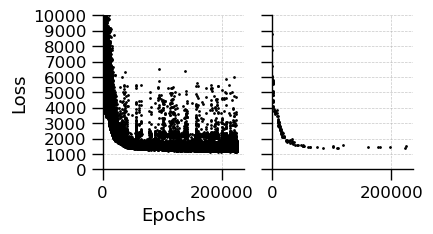

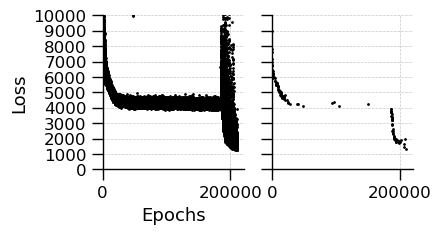

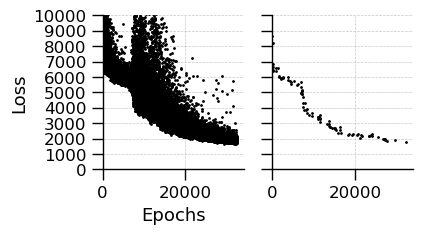

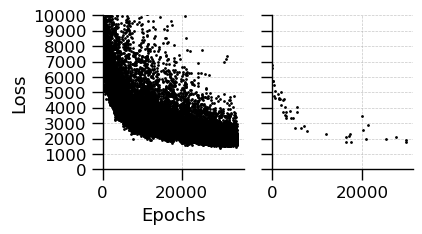

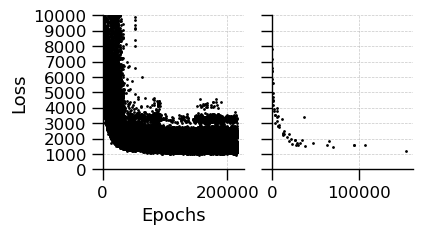

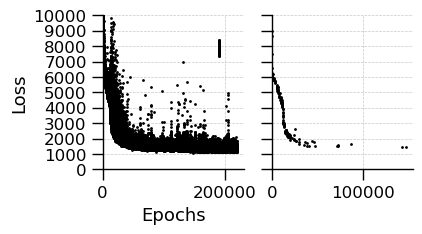

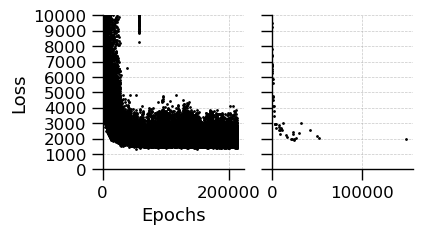

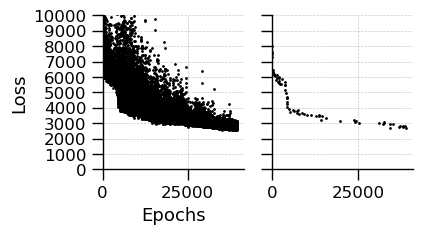

In [32]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 300ms integration, *with* heterogeneity

In [9]:
data_paths = [
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:39:22.419915_run_000750',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:39:57.149671_run_000751',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:39:57.052713_run_000752',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:39:50.990124_run_000753',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:39:50.241391_run_000754',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:39:51.663809_run_000755',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:39:52.376865_run_000756',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:39:52.587371_run_000757',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:39:55.972538_run_000758',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:39:56.752124_run_000759',
]

In [ ]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

4908.109445871591


### 2D network, 1s integration, 300ms input, no heterogeneity

In [3]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:43:52.531779_run_000860',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:43:52.531768_run_000861',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:43:52.571859_run_000862',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:43:53.616936_run_000863',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:43:53.616932_run_000864',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:43:52.076391_run_000865',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:43:52.554505_run_000866',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:43:52.554512_run_000867',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:43:52.554509_run_000868',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:43:51.815465_run_000869',
]

1411.9519469572872
2269.5389991573893
1407.8981303671749
1490.2025141172367
1799.816874197169
1519.5573877756692
1087.941442030142
1443.2986953446564
1415.128689759824
2537.362019466367
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:43:52.531779_run_000860
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:43:52.571859_run_000862
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:43:53.616936_run_000863
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:43:53.616932_run_000864
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:43:52.076391_run_000865
2D_long_reverted_time_1.

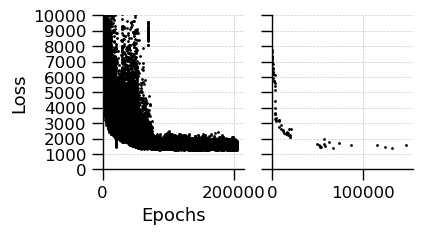

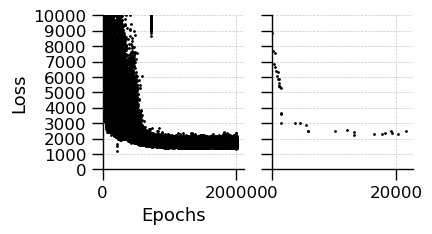

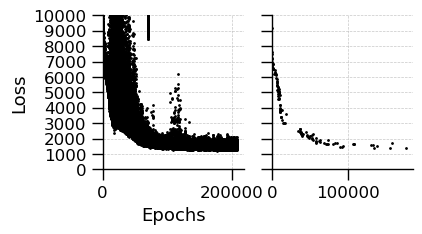

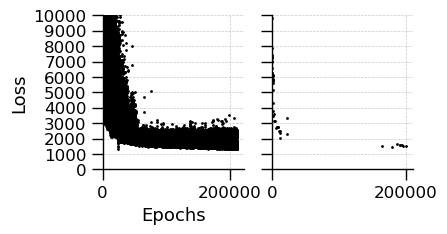

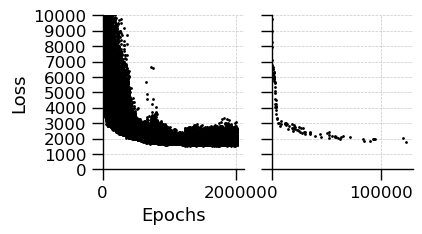

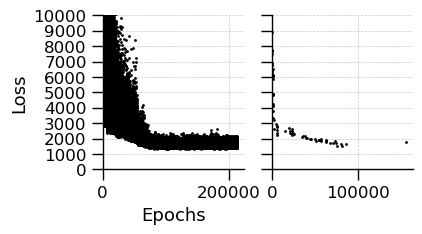

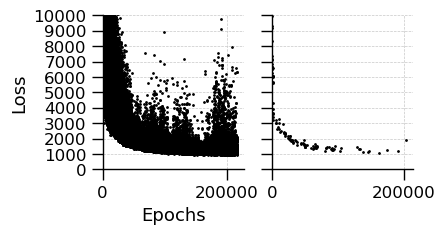

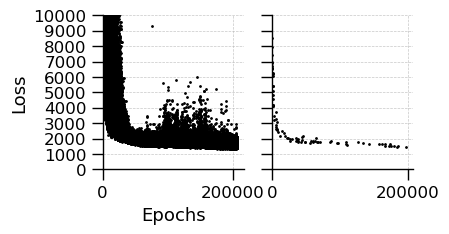

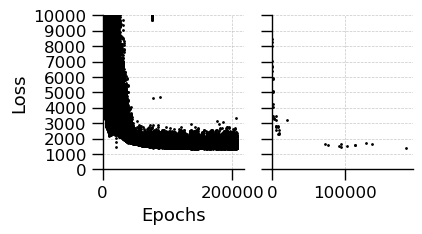

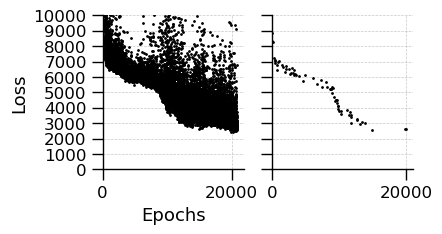

In [4]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 1s integration, 300ms input, *with* heterogeneity

In [5]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:40:52.909148_run_000800',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:40:53.471516_run_000801',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:40:50.790337_run_000802',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:40:52.210765_run_000803',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:40:52.210763_run_000804',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:40:52.210764_run_000805',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:40:52.070684_run_000806',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:40:52.070681_run_000807',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:40:52.070684_run_000808',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:40:52.070687_run_000809',
]

1704.9764424446143
2133.7308229430123
2105.4495154084457
2146.0321120677095
2536.2452490541664
5326.973099041642
2217.0098576817027
5839.03491267243
2239.8839044865294
2043.1717250787551
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:40:52.909148_run_000800
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:40:53.471516_run_000801
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:40:50.790337_run_000802
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:40:52.210765_run_000803
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:40:52.070684_run_000806
2D_long_rever

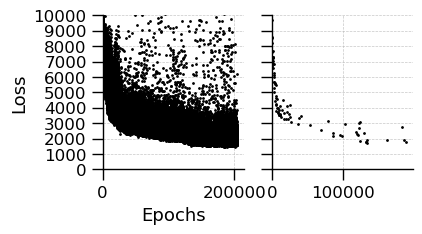

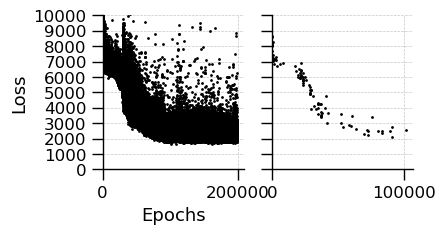

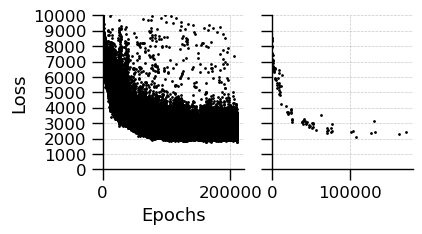

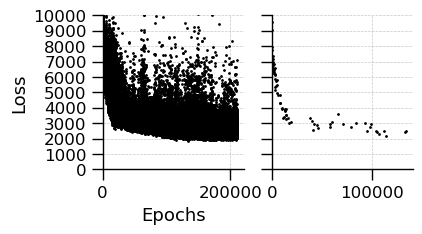

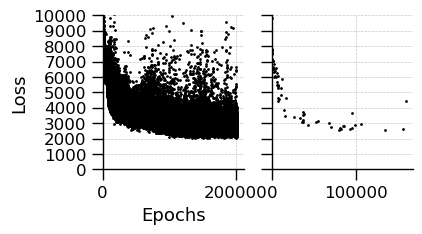

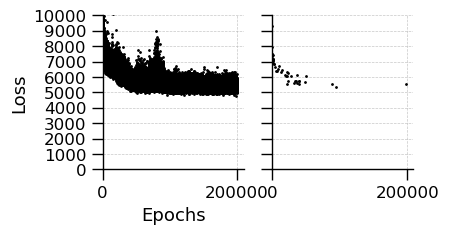

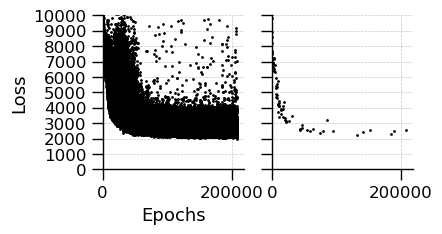

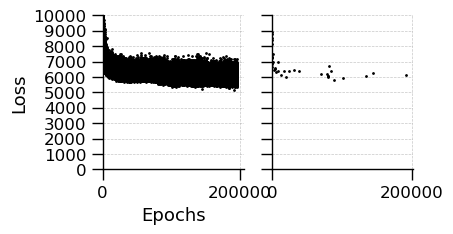

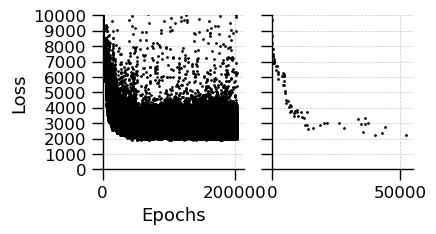

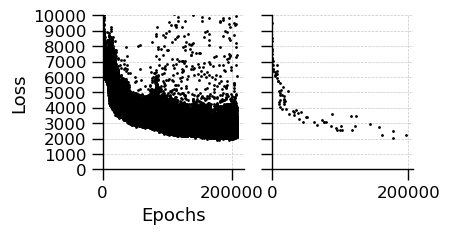

In [6]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

# 5 unit networks

### 5 unit network, 300s integration, 300ms input, *with* heterogeneity
I raised the minimum probably of getting an input at any timestep here from 0.1 to 0.25, so inputs are more frequent across all networks in this version of the task.

In [3]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:59:58.750596_run_000640',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:59:58.965856_run_000641',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_01:00:05.422898_run_000642',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_01:00:05.422910_run_000643',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_01:00:05.422899_run_000644',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_01:00:05.422896_run_000645',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_01:00:05.422905_run_000646',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_01:00:06.209025_run_000647',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_01:00:06.209034_run_000648',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_01:00:06.209026_run_000649',
]

3726.448665466186
2577.5518933739963
4217.026274317766
4319.942735849929
2655.102177816854
2861.649114982542
2691.0916011116237
2543.2648783753953
2637.5547948337203
2621.6270806773423


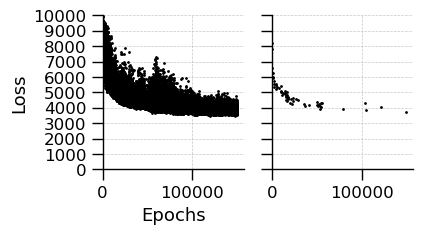

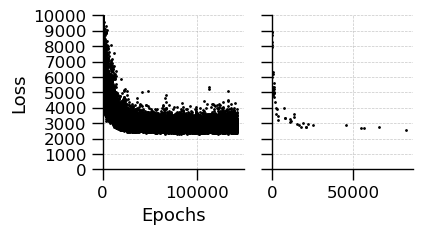

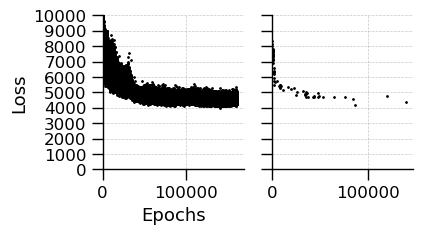

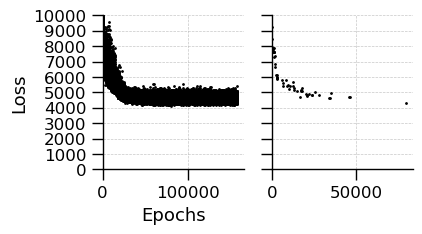

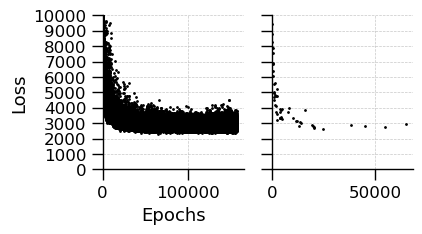

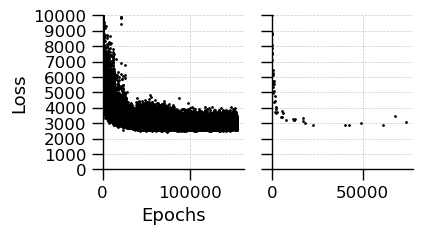

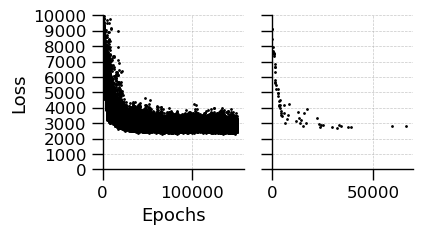

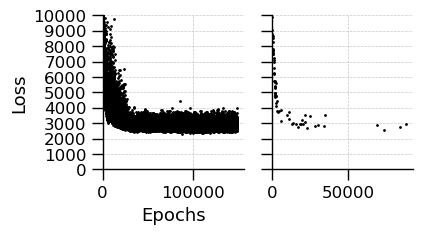

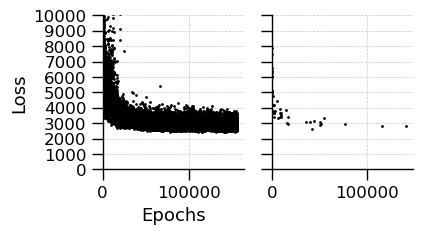

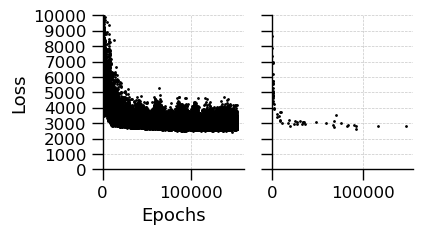

In [4]:
plot_losses(data_paths, xlim=(0, None), thresh=2500) #2800

### 5 unit network, 300ms integration, 300ms input, no heterogeneity

In [5]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:57:27.144748_run_000670',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:57:31.037464_run_000671',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:57:31.037462_run_000672',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:57:30.863035_run_000673',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:57:30.863039_run_000674',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:57:30.863037_run_000675',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:57:30.863034_run_000676',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:57:30.863036_run_000677',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:57:31.762208_run_000678',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:57:31.762178_run_000679',
]

5887.5122414102625
3821.6581572976347
3503.139606619218
3771.3377068632567
2346.1403704807262
2110.5657064556412
3794.6591981939937
2411.5904522291844
2231.1885456055184
4447.354672343599
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:57:30.863039_run_000674
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:57:30.863037_run_000675
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:57:30.863036_run_000677
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:57:31.762208_run_000678


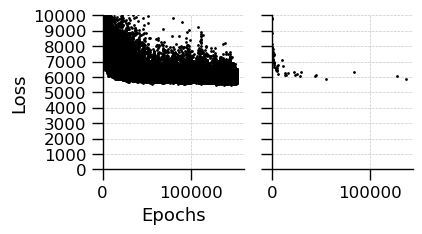

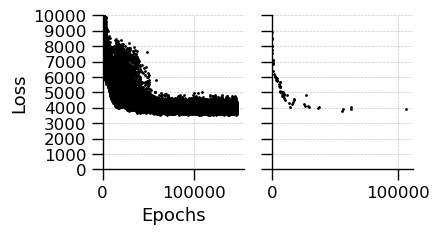

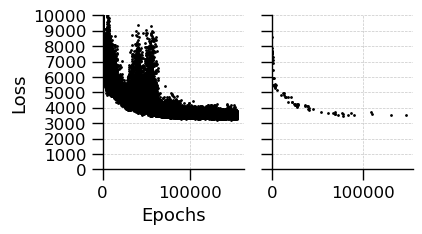

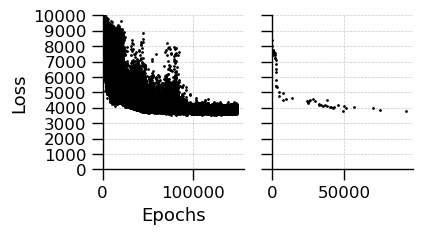

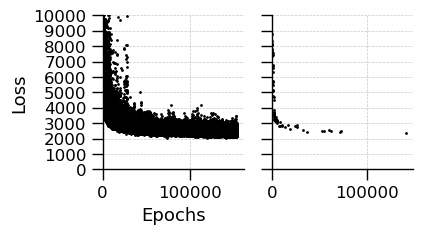

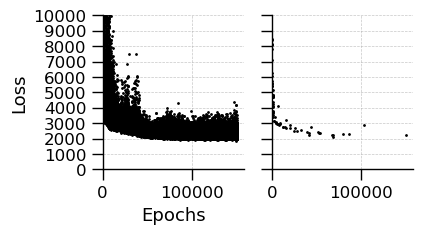

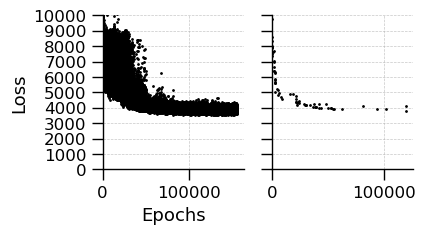

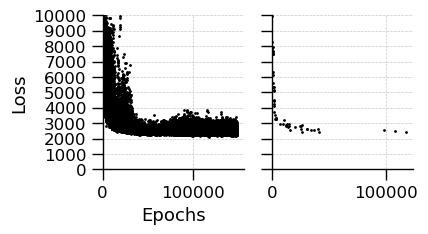

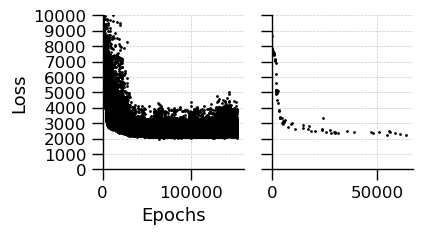

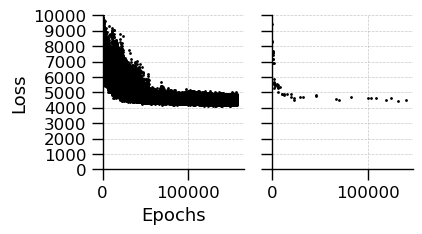

In [6]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [7]:
data_paths = [
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:58:27.683449_run_000680',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:58:27.571300_run_000681',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:58:27.733756_run_000682',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:58:27.677570_run_000683',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:58:32.274485_run_000684',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:58:32.274516_run_000685',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:58:32.274490_run_000686',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:58:34.869830_run_000687',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:58:34.869828_run_000688',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:58:34.869832_run_000689',
]

1504.3015905906518
3060.982128862494
1494.9321552539711
2954.7246267933688
3047.978949333841
3128.9926600959275
2232.8404747461595
8953.190337350175
3035.5819838102307
2419.4065116957777
n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:58:27.683449_run_000680
n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:58:27.733756_run_000682
n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:58:27.677570_run_000683
n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:58:32.274490_run_000686
n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:58:34.869832_run_

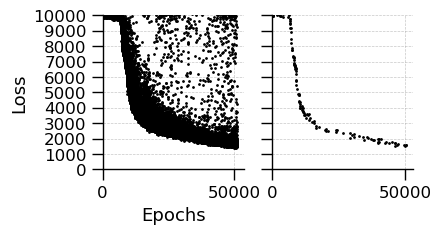

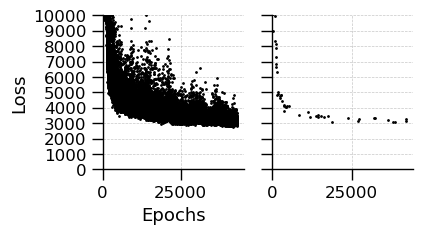

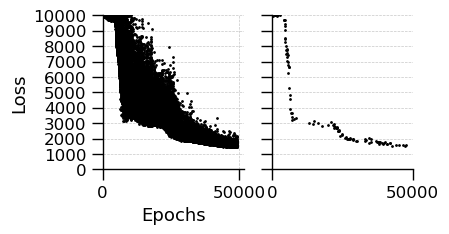

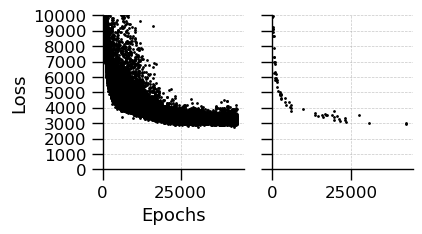

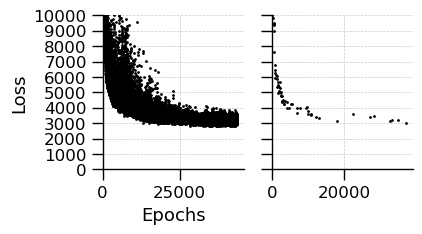

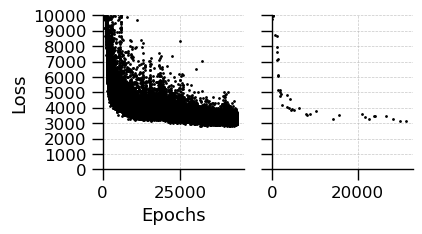

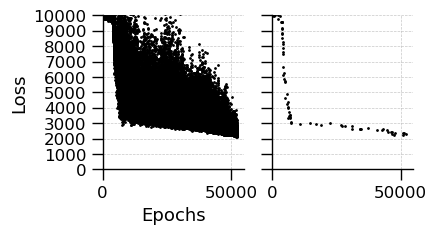

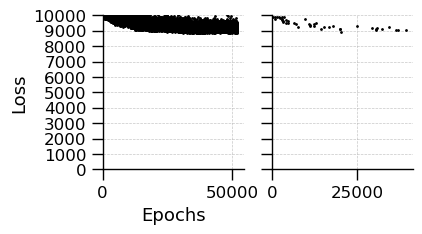

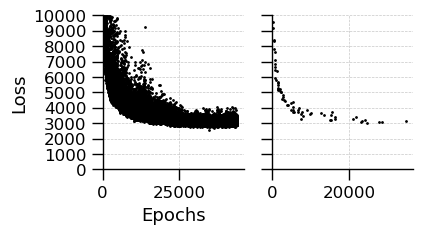

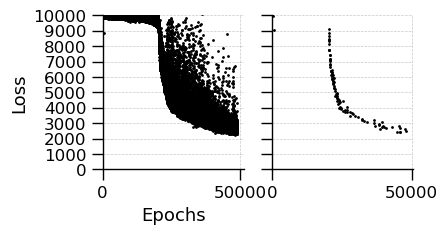

In [8]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

In [5]:
data_paths = [
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_01:01:09.648873_run_000690',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_01:01:01.451109_run_000691',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_01:01:01.451112_run_000692',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_01:01:01.451093_run_000693',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_01:00:59.224117_run_000694',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_01:01:04.811582_run_000695',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_01:01:04.811583_run_000696',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_01:01:04.811586_run_000697',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_01:01:04.811586_run_000698',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_01:01:03.658076_run_000699',
]

3456.9611811578498
3240.3213745301437
2989.6754377050474
9043.61223502926
9190.5341810619
2947.8366080655683
2484.3033810630445
4606.40170193783
2878.1953165009445
5004.601128296896
n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_01:01:01.451112_run_000692
n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_01:01:04.811582_run_000695
n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_01:01:04.811583_run_000696
n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_01:01:04.811586_run_000698


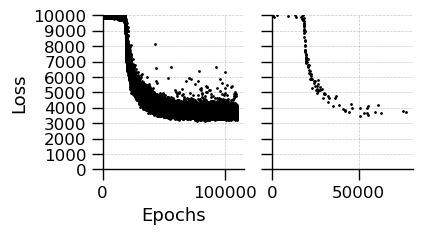

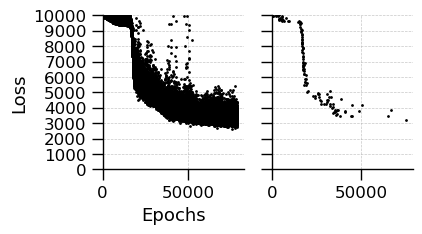

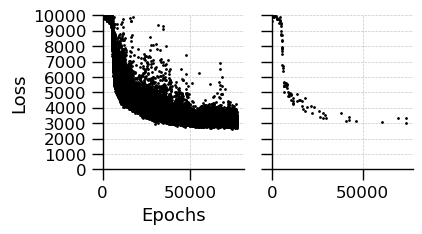

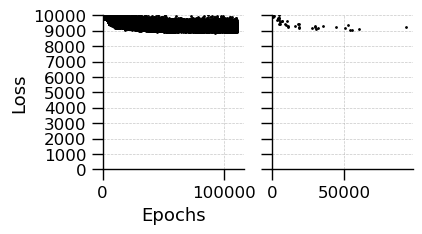

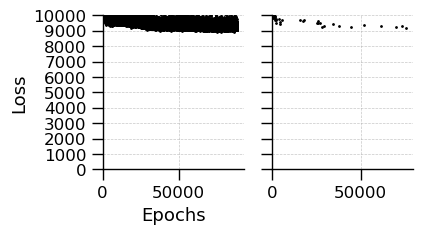

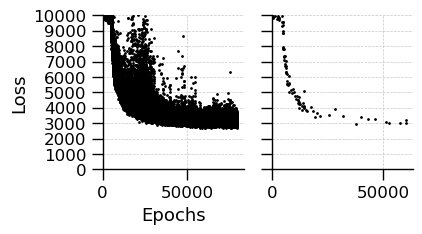

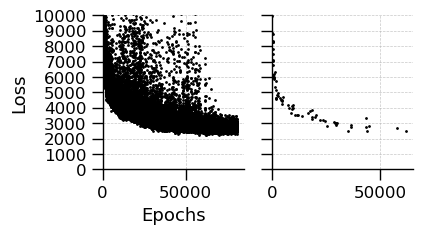

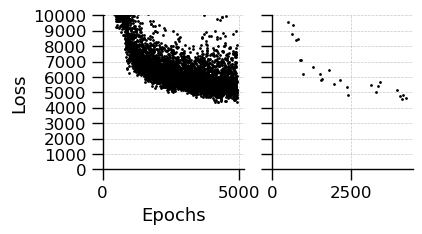

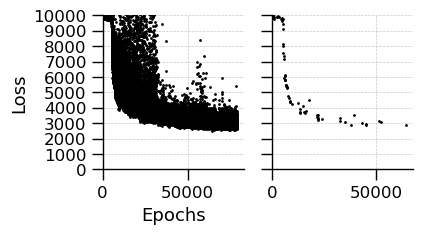

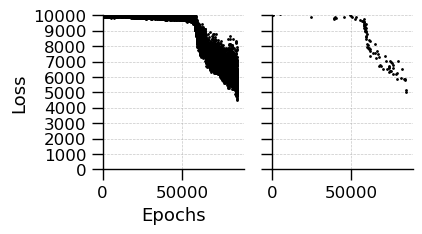

In [6]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

In [12]:
data_paths = [
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-14_14:31:22.319211_run_001020',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-14_14:31:53.298330_run_001021',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-14_14:31:41.500748_run_001022',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-14_14:31:41.500744_run_001023',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-14_14:31:41.500749_run_001024',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-14_14:31:41.248270_run_001025',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-14_14:31:41.248274_run_001026',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-14_14:31:41.785140_run_001027',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-14_14:31:41.785161_run_001028',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-14_14:31:44.067886_run_001029',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8010_2025-12-14_17:02:21.586823_run_001030',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8011_2025-12-14_17:02:22.375142_run_001031',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8012_2025-12-14_17:02:22.375146_run_001032',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8013_2025-12-14_17:02:25.966260_run_001033',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8014_2025-12-14_17:02:25.722226_run_001034',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-12-14_15:28:00.354021_run_001035',
    'n5_short_min_pactive_0p25_shift_init_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2025-12-14_15:28:00.354016_run_001036',
]

In [ ]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

6463.049525645364


In [8]:
data_paths = [
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-14_23:49:54.964844_run_001040',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-14_23:49:53.859125_run_001041',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-14_23:49:54.690046_run_001042',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-14_23:49:54.690047_run_001043',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-14_23:49:55.466216_run_001044',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-14_23:49:55.466223_run_001045',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-14_23:49:55.466217_run_001046',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-14_23:49:55.466220_run_001047',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-14_23:49:55.466217_run_001048',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-14_23:49:55.466215_run_001049',
]

2345.50313305727
2690.648761075654
2673.4330671992993
2614.411719246196
2519.207238789879
2733.2274875418616
2354.5454606803646
2525.375650525757
2352.043567165998
2415.610687389547
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-14_23:49:54.964844_run_001040
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-14_23:49:55.466217_run_001046
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-14_23:49:55.466217_run_001048
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-14_23:49:55.466215_run_001049


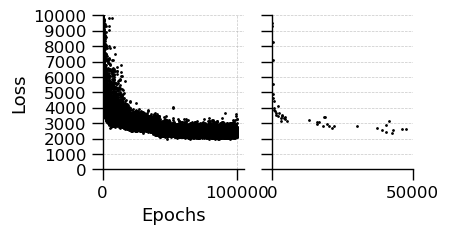

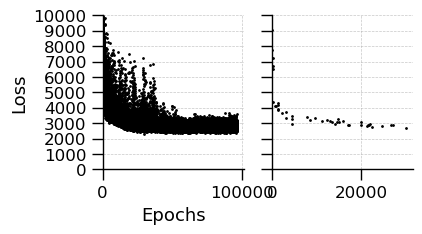

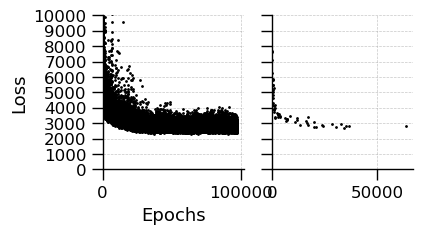

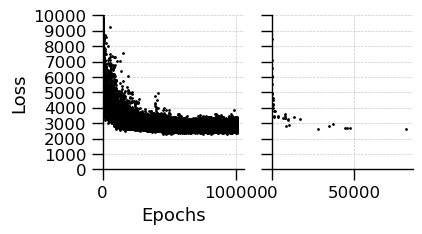

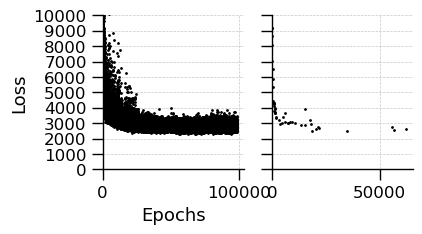

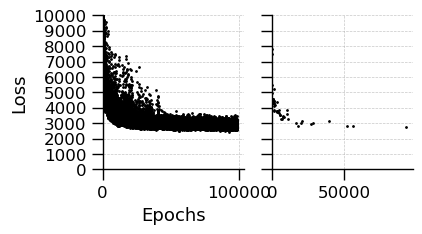

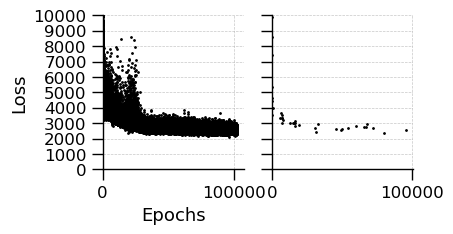

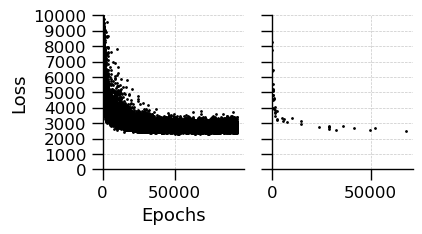

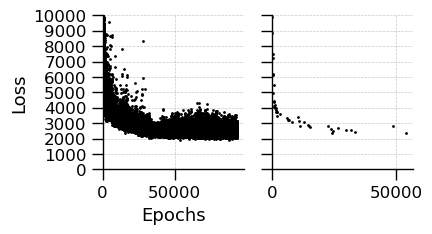

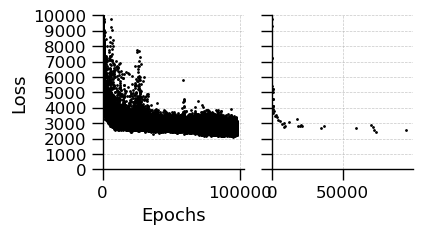

In [9]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [7]:
data_paths = [
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-15_16:57:24.909299_run_001060',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-15_16:57:24.909297_run_001061',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-15_16:57:24.909281_run_001062',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-15_16:57:19.102375_run_001063',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-15_16:57:19.102379_run_001064',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-15_16:57:28.789866_run_001065',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-15_16:57:28.789868_run_001066',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-15_16:57:18.930880_run_001067',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-15_16:57:18.930871_run_001068',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-15_16:57:19.534858_run_001069',
]

3457.5441120225623
2367.6892936966074
2422.2875310200493
2342.2098563415757
2239.463447107475
2493.462899070487
2404.8088285618164
2351.1502067259466
2135.4664689769315
2357.160377974346
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-15_16:57:24.909297_run_001061
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-15_16:57:24.909281_run_001062
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-15_16:57:19.102375_run_001063
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-15_16:57:19.102379_run_001064
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_

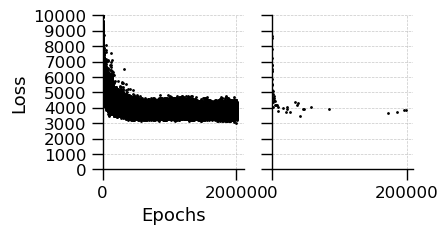

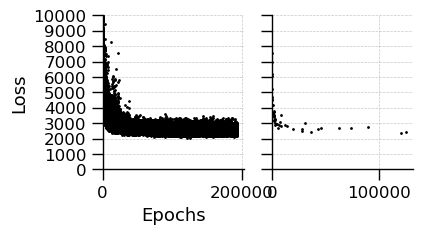

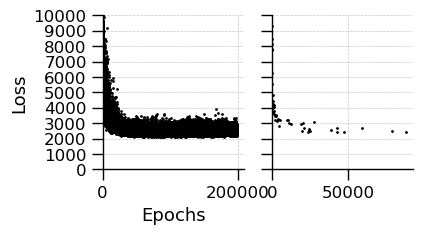

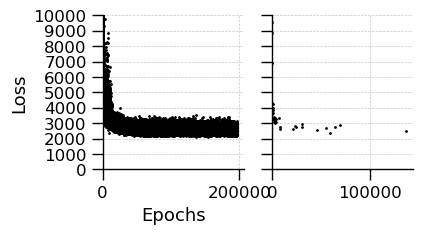

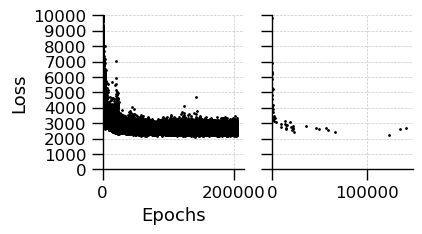

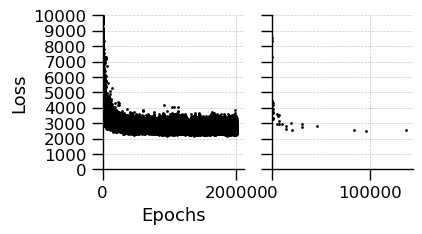

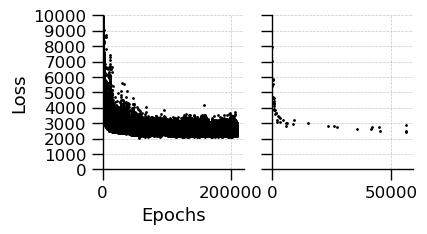

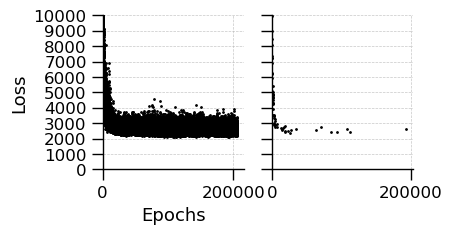

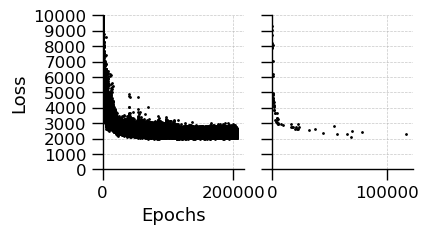

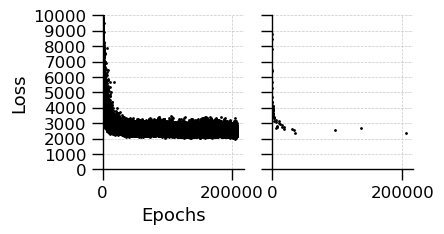

In [8]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [6]:
data_paths = [
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-15_16:49:42.984392_run_001050',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-15_16:49:43.857762_run_001051',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-15_16:49:43.857767_run_001052',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-15_16:49:43.857779_run_001053',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-15_16:49:43.857768_run_001054',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-15_16:49:57.879869_run_001055',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-15_16:49:57.879884_run_001056',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-15_16:49:57.879850_run_001057',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-15_16:49:43.063382_run_001058',
    'n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-15_16:49:43.482802_run_001059',
]

2067.0391765504805
1609.6280921942598
1707.093532583036
1529.484605547173
1725.6939198128225
1648.1973259230363
1771.5567118144559
1665.555834725485
1608.5954666338223
1770.90179543097
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-15_16:49:43.857762_run_001051
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-15_16:49:43.857767_run_001052
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-15_16:49:43.857779_run_001053
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-15_16:49:43.857768_run_001054
n5_short_min_pactive_0p25_diag_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_202

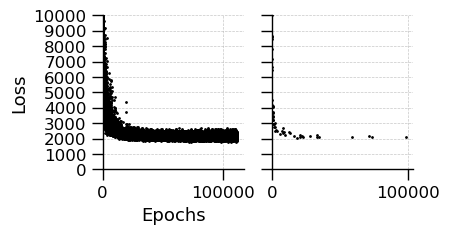

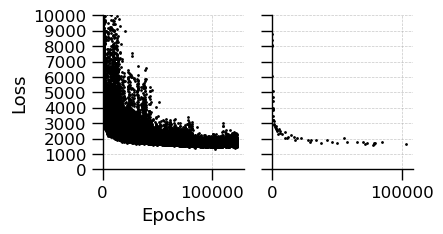

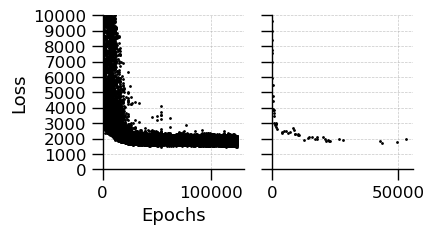

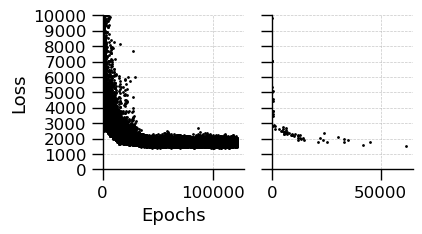

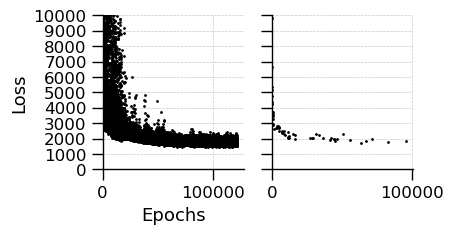

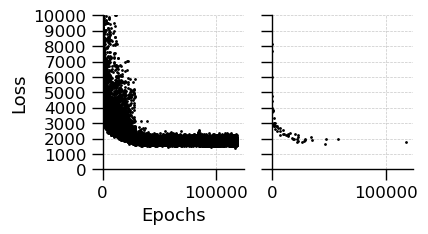

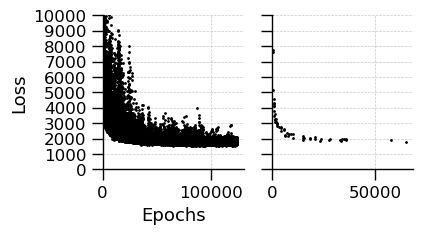

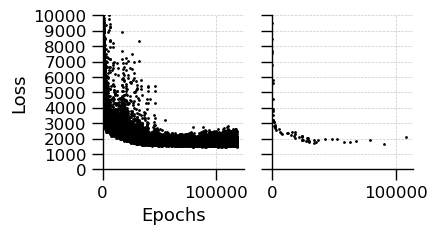

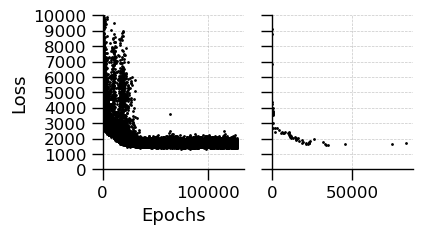

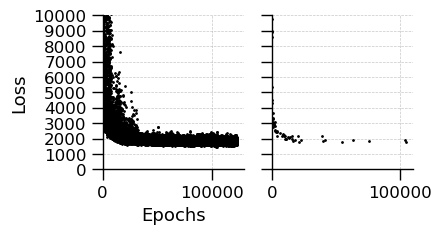

In [7]:
plot_losses(data_paths, xlim=(0, None), thresh=1800)

In [9]:
data_paths = [
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-17_00:51:04.952997_run_001080',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-17_00:51:04.953020_run_001081',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-17_00:51:04.953028_run_001082',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-17_00:51:04.953006_run_001083',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-17_00:51:04.953018_run_001084',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-17_00:51:01.639121_run_001085',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-17_00:50:58.053413_run_001086',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-17_00:50:58.378274_run_001087',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-17_00:53:09.063933_run_001088',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-17_00:54:43.490456_run_001089',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8010_2025-12-17_00:54:43.490461_run_001090',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8011_2025-12-17_00:54:43.490458_run_001091',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8012_2025-12-17_00:54:43.490458_run_001092',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8013_2025-12-17_00:54:43.490457_run_001093',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8014_2025-12-17_00:54:43.490464_run_001094',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-12-17_00:58:21.915504_run_001095',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2025-12-17_00:58:51.112190_run_001096',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2025-12-17_00:58:45.754869_run_001097',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8018_2025-12-17_01:00:23.590730_run_001098',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8019_2025-12-17_01:00:23.590700_run_001099',
]

3372.434278310556
2768.864576287763
4793.0185508439
6586.36501958145
4730.482000541817
9084.548468940207
3017.006885873664
4163.238907946684
2749.352830421632
2924.5663906534037
2939.823162561359
6211.262761592164
4680.528472921249
3172.7919527139875
2970.8677817662083
2848.529296790624
3005.34569453244
2806.3660285458936
2744.648738283393
6057.530086618329
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-17_00:51:04.953020_run_001081
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-17_00:53:09.063933_run_001088
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-17_00:54:43.490456_run_001089
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1

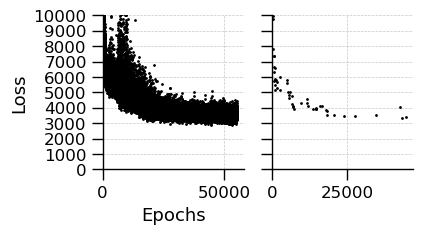

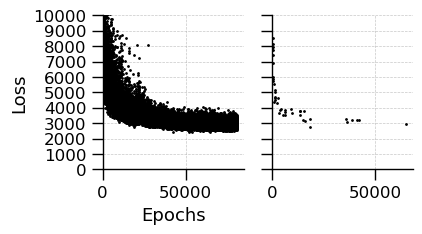

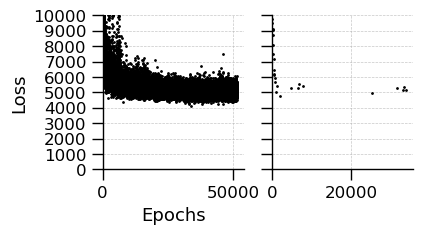

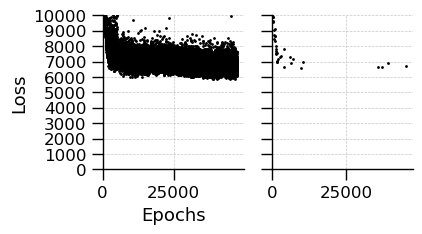

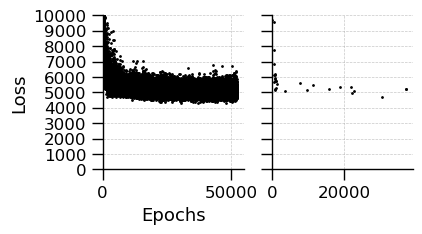

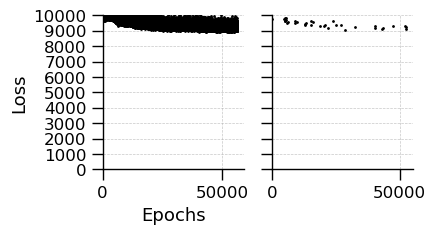

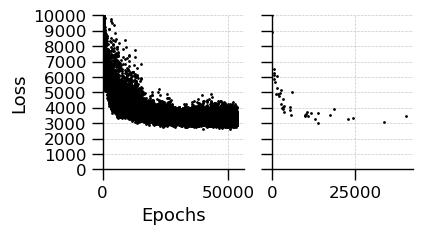

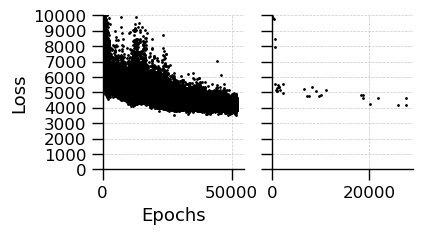

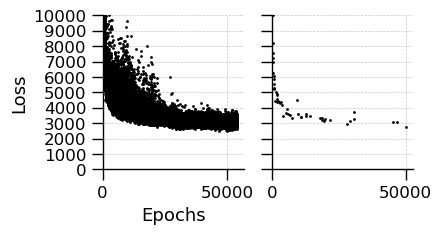

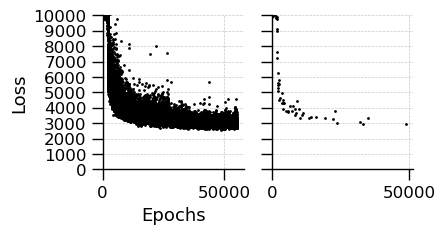

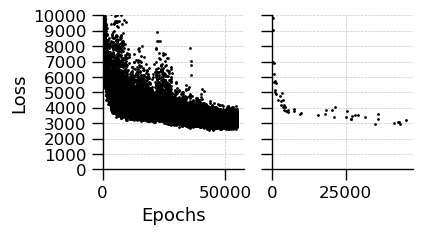

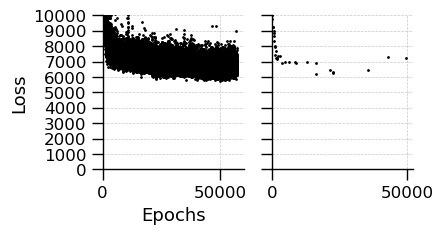

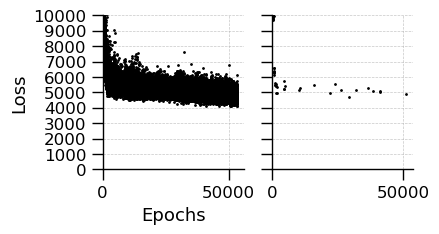

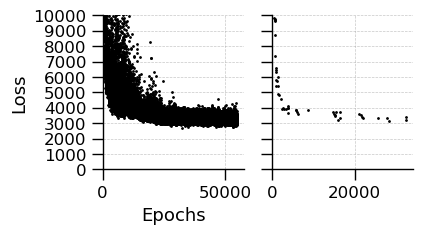

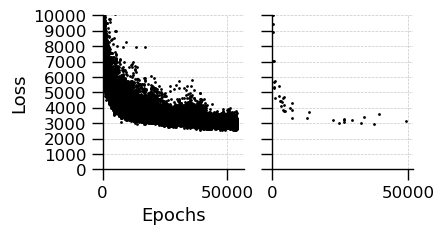

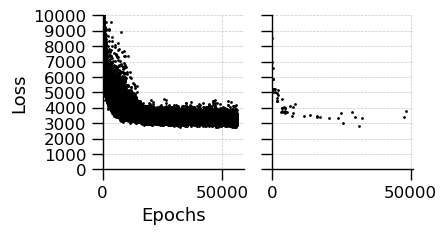

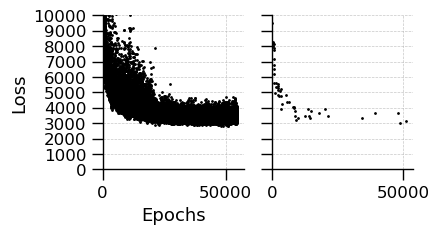

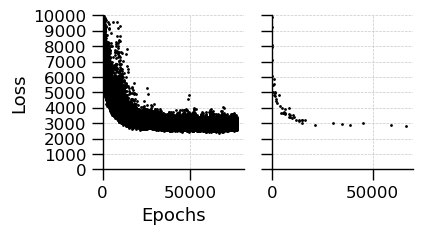

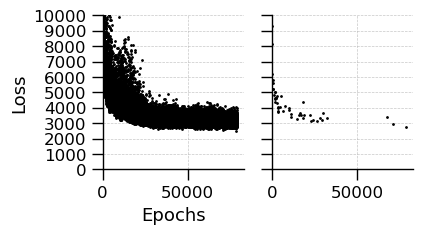

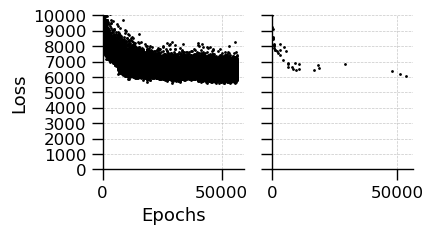

In [10]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

In [3]:
data_paths = [
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-17_01:00:23.590725_run_001100',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-17_01:00:22.397435_run_001101',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-17_01:00:23.673712_run_001102',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-17_01:00:23.673712_run_001103',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-17_01:00:22.765710_run_001104',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-17_01:00:22.765763_run_001105',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-17_01:00:22.643831_run_001106',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-17_01:01:54.283012_run_001107',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-17_01:01:54.283018_run_001108',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8010_2025-12-17_01:01:54.283015_run_001110',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8011_2025-12-17_01:02:23.618715_run_001111',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8012_2025-12-17_01:02:29.754142_run_001112',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8013_2025-12-17_01:02:29.754142_run_001113',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8014_2025-12-17_01:02:29.754146_run_001114',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-12-17_01:02:29.754143_run_001115',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2025-12-17_01:02:29.754142_run_001116',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2025-12-17_01:02:29.754144_run_001117',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8018_2025-12-17_01:04:01.445293_run_001118',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8019_2025-12-17_01:04:34.071062_run_001119',
]

2261.783282586027
2128.3915594656073
2003.9575492671106
1920.460396426679
2288.4120906152875
2171.643526568082
2227.0217626035355
2255.5816303640727
2145.6661381356585
2069.866047642975
2297.3895604754075
2112.5573301465165
2158.20592426629
2753.9935000058845
3200.2878776693856
2487.601018898929
2412.494879075051
2053.839858041458
1351.929084135456
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-17_01:00:22.397435_run_001101
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-17_01:00:23.673712_run_001102
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-17_01:00:23.673712_run_001103
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_AC

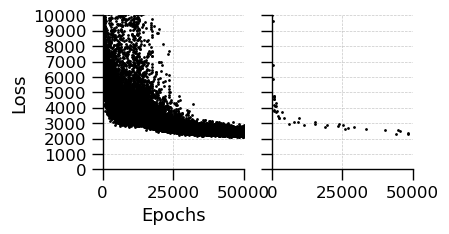

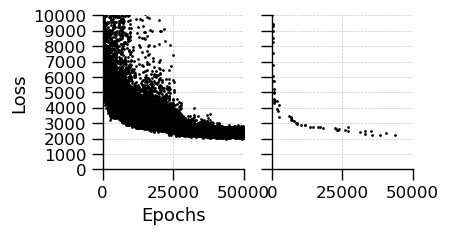

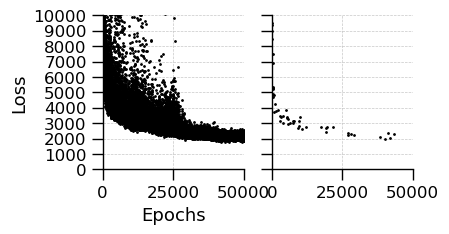

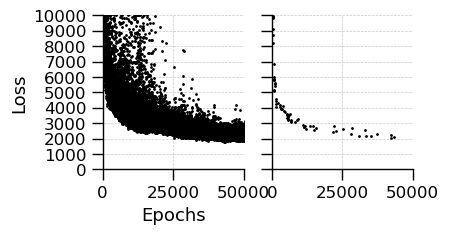

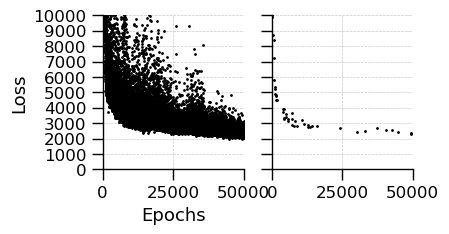

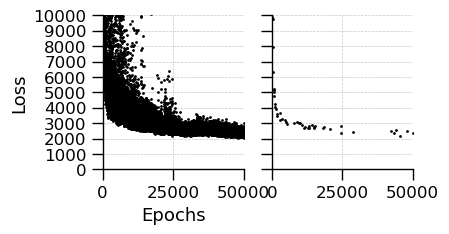

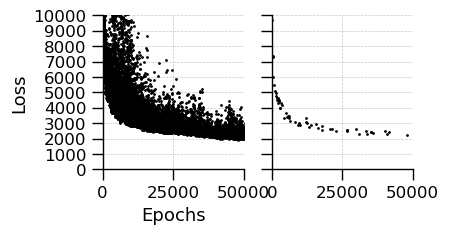

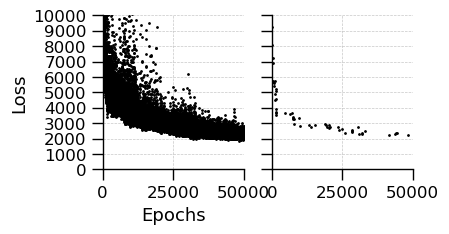

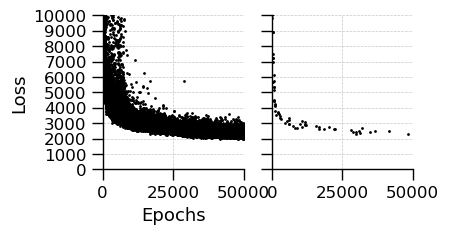

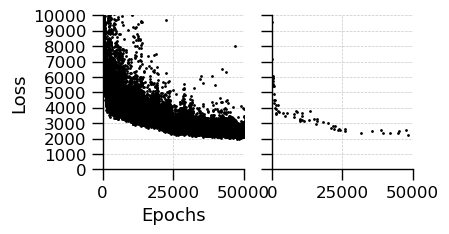

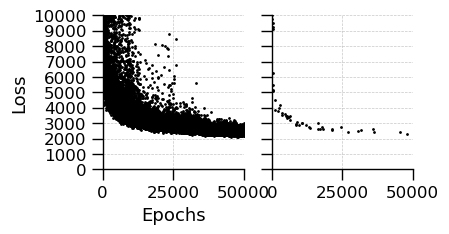

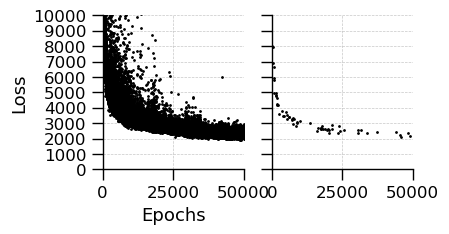

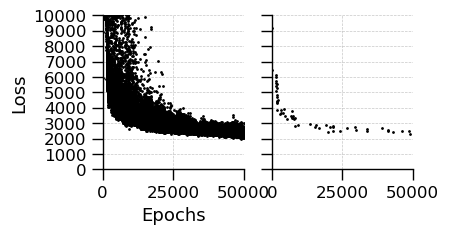

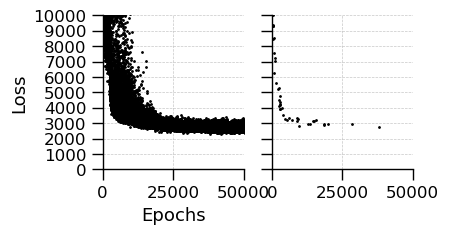

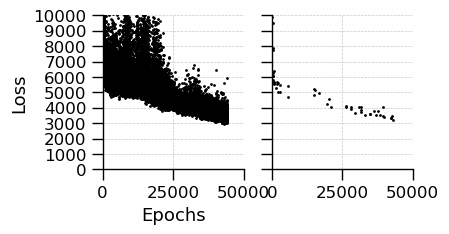

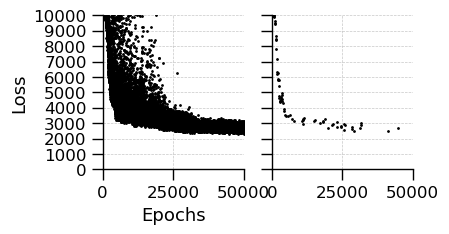

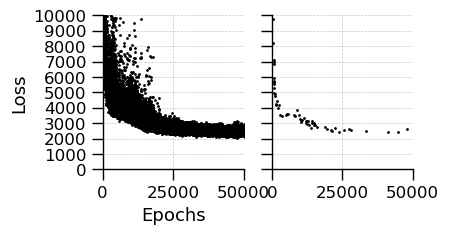

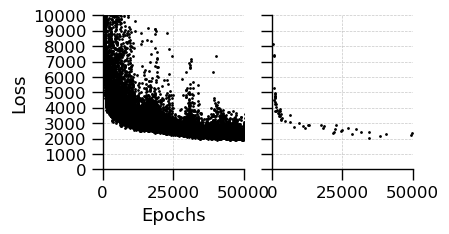

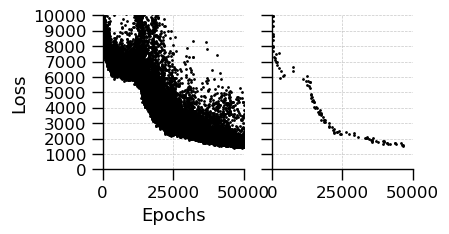

In [4]:
plot_losses(data_paths, xlim=(0, 50000), thresh=2200)

In [5]:
data_paths = [
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2026-02-18_23:54:01.305727_run_001200',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2026-02-18_23:54:06.364974_run_001201',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2026-02-18_23:54:06.364695_run_001202',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2026-02-18_23:54:06.364701_run_001203',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2026-02-18_23:54:07.369016_run_001204',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2026-02-18_23:54:07.369020_run_001205',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2026-02-18_23:54:07.369014_run_001206',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2026-02-18_23:54:07.369015_run_001207',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2026-02-18_23:54:07.369021_run_001208',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2026-02-18_23:54:07.369013_run_001209',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8010_2026-02-18_23:54:07.582612_run_001210',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8011_2026-02-18_23:54:07.582608_run_001211',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8012_2026-02-18_23:54:07.582615_run_001212',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8013_2026-02-18_23:54:07.582614_run_001213',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8014_2026-02-18_23:54:07.582611_run_001214',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2026-02-18_23:54:07.582618_run_001215',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2026-02-18_23:54:07.142175_run_001216',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2026-02-18_23:54:07.142172_run_001217',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8018_2026-02-18_23:54:07.142175_run_001218',
    'n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8019_2026-02-18_23:54:07.142169_run_001219',
]

2506.146637023569
2502.9184734446817
2222.095648839996
2416.0487489448606
2251.8656204447493
2233.282766520911
2562.5975865104597
2594.394048525119
2554.834239990543
2438.784047749043
2511.905703743928
2383.1571036429764
2388.9531025776278
2235.833238300816
2431.469329885792
2338.973730270522
2361.1134916714723
2347.2099493304504
2322.7136143591074
2326.7687907767686
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2026-02-18_23:54:01.305727_run_001200
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2026-02-18_23:54:06.364974_run_001201
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2026-02-18_23:54:06.364695_run_001202
n5_short_min_pactive_0p25_diag_small_bump_0.3_inp_0.27_het_0.1_shift_10_TH_0_STD_

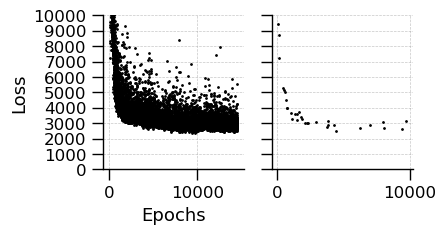

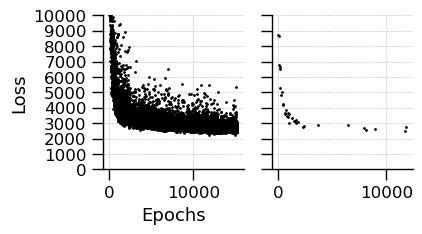

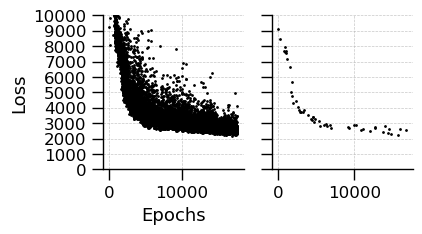

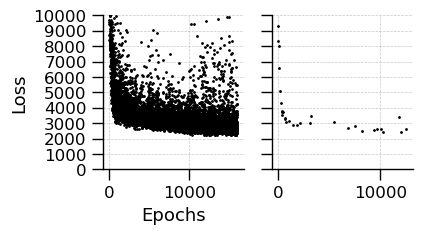

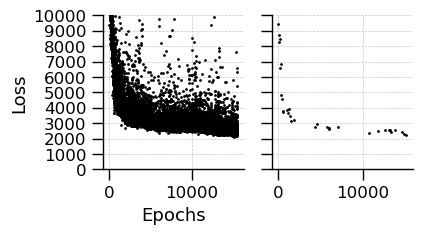

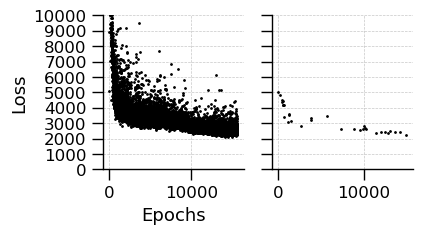

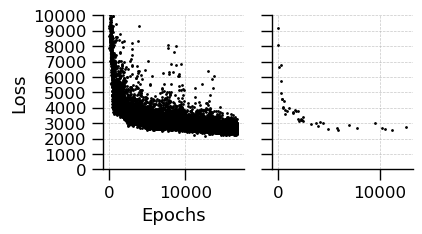

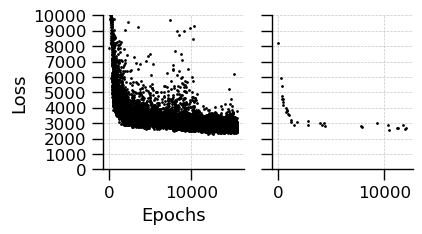

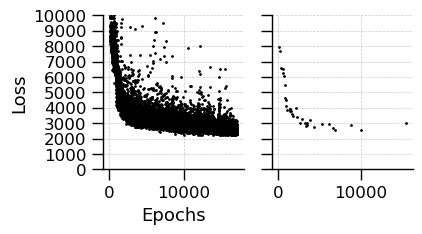

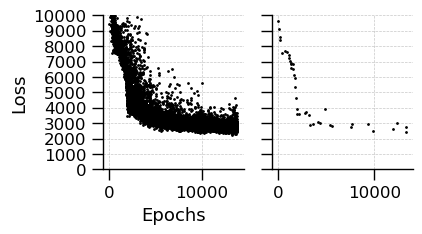

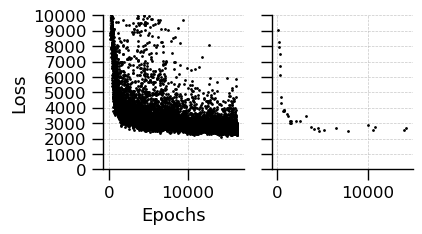

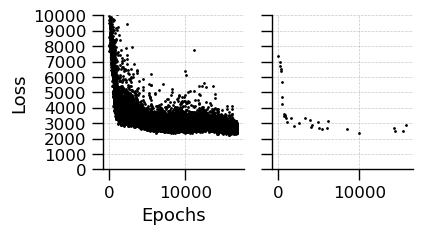

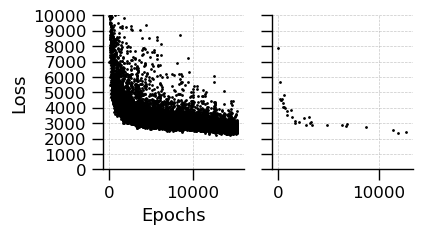

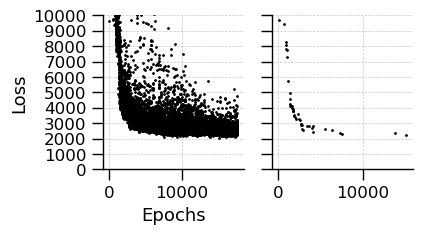

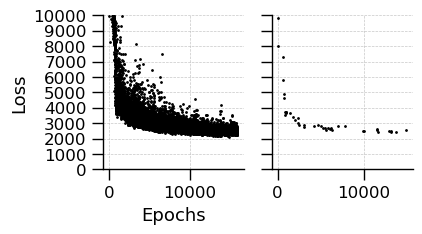

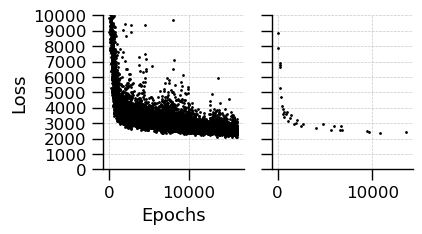

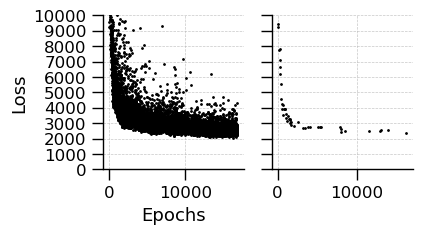

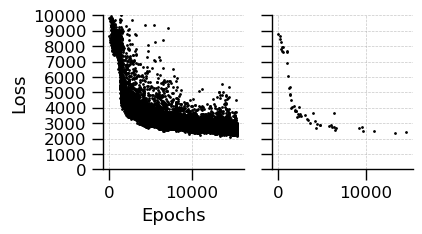

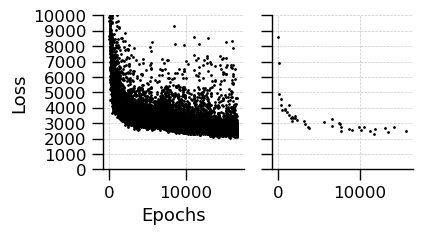

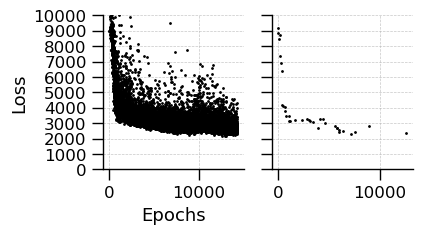

In [6]:
plot_losses(data_paths, xlim=None, thresh=4000)

In [3]:
data_paths = [
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2026-02-18_23:45:09.618079_run_001220',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2026-02-18_23:45:13.989047_run_001221',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2026-02-18_23:45:17.557075_run_001222',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2026-02-18_23:45:17.557079_run_001223',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2026-02-18_23:45:11.157215_run_001224',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2026-02-18_23:45:11.157218_run_001225',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2026-02-18_23:45:11.081006_run_001226',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2026-02-18_23:45:11.081010_run_001227',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2026-02-18_23:45:04.349760_run_001228',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2026-02-18_23:45:17.804550_run_001229',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8010_2026-02-18_23:45:17.804547_run_001230',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8011_2026-02-18_23:45:17.804548_run_001231',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8012_2026-02-18_23:45:11.078428_run_001232',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8013_2026-02-18_23:45:11.078426_run_001233',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8014_2026-02-18_23:45:06.182802_run_001234',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2026-02-18_23:45:06.182801_run_001235',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8016_2026-02-18_23:45:06.182803_run_001236',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8017_2026-02-18_23:45:06.182800_run_001237',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8018_2026-02-18_23:45:06.182800_run_001238',
    'n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8019_2026-02-18_23:45:06.182794_run_001239',
]

5017.8185560155725
3696.866329107636
3970.935774997315
9089.882749315908
3737.632569146619
3489.0684356513607
7146.6607723749785
9694.477742261346
6854.65647037714
9789.101716156154
3377.0389685959453
5009.508014815371
3296.271667224546
3405.187507953131
3674.582469793037
6317.479263707706
3717.381578509603
3469.843459029516
3617.429049971487
3888.7022877544027
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2026-02-18_23:45:13.989047_run_001221
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2026-02-18_23:45:17.557075_run_001222
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2026-02-18_23:45:11.157215_run_001224
n5_long_min_pactive_0p25_diag_small_bump_1.0_inp_0.27_het_0.1_shift_10_TH_0_STD_EXPL_0.001

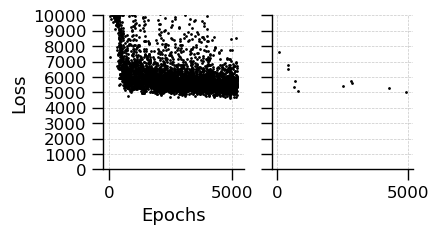

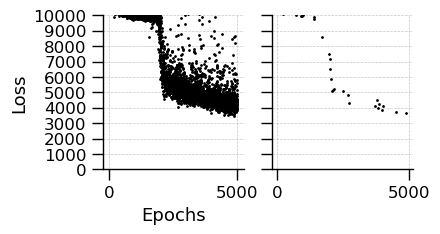

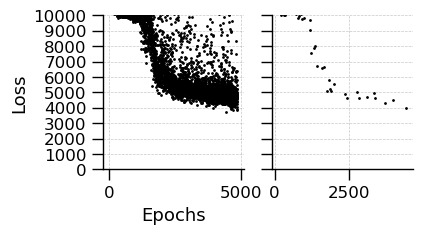

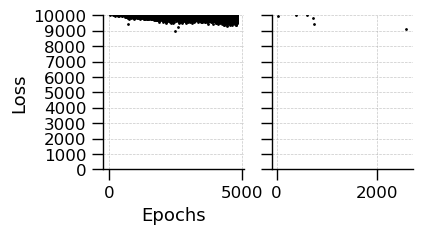

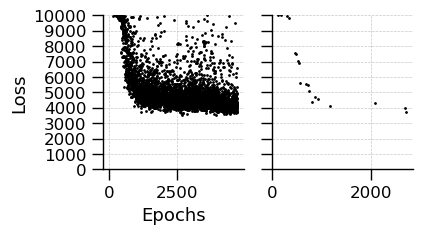

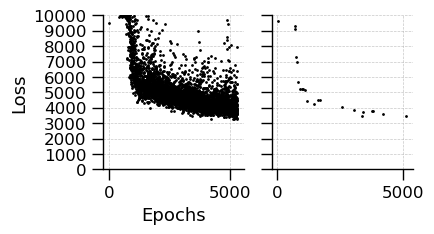

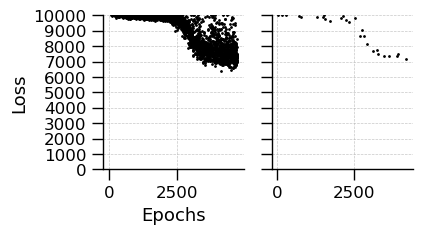

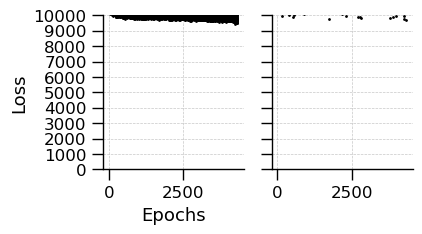

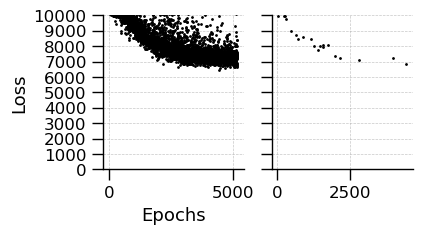

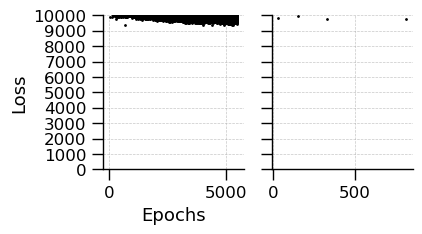

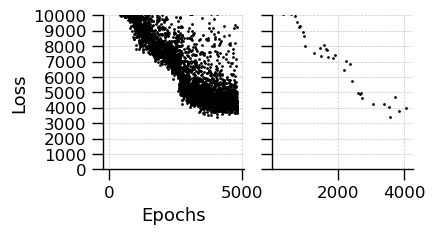

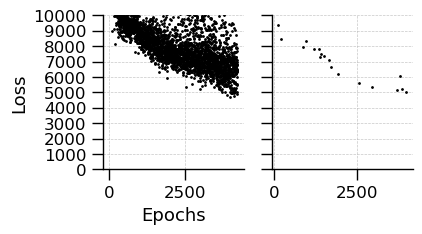

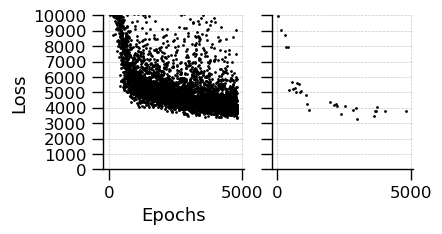

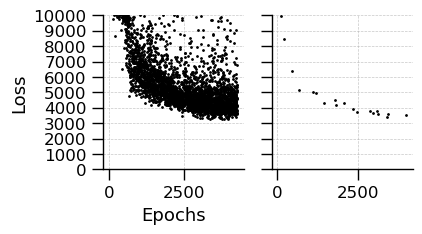

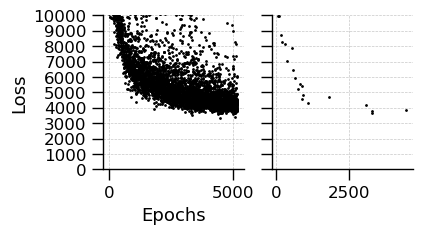

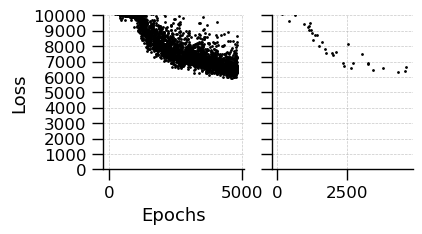

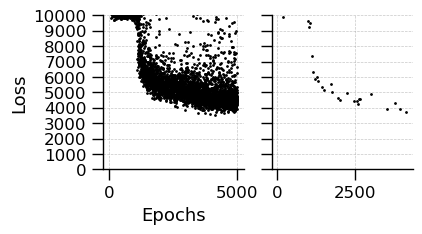

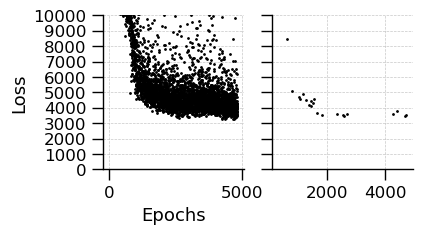

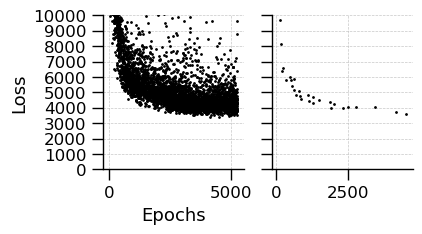

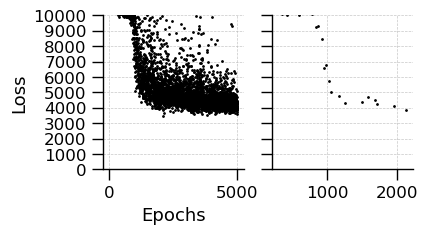

In [4]:
plot_losses(data_paths, xlim=None, thresh=4000)